<a href="https://colab.research.google.com/github/MahendraVarma17/internship_projects/blob/main/Skill_Graph_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.decomposition import PCA
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("/content/task11_realistic_student_skill_dataset.csv")

df.head()

,Student_ID,Skill_Name,Skill_Category,Skill_Score,Assessment_Score,Course_Completion_Percentage,Learning_Hours,Assignment_Completion_Rate,Login_Frequency,Proficiency_Level,Skill_Gap,Recommended_Learning_Hours,Learning_Priority,Future_Skill_Score
0,S064,Node.js,Web Development,22.0,33.0,13.0,66.0,22.0,0.0,Beginner,63,57,High,32
1,S070,JavaScript,Web Development,64.0,53.0,36.0,49.0,35.0,7.0,Intermediate,21,23,Medium,42
2,S055,Git & GitHub,Tools,38.0,52.0,61.0,45.0,42.0,16.0,Beginner,47,44,High,41
3,S030,CSS,Web Development,52.0,36.0,62.0,33.0,41.0,13.0,Beginner,33,34,High,62
4,S065,Problem Solving,Soft Skills,46.0,63.0,66.0,107.0,60.0,4.0,Beginner,39,24,High,42


In [3]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1807 entries, 0 to 1806
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    1807 non-null   object 
 1   Skill_Name                    1807 non-null   object 
 2   Skill_Category                1796 non-null   object 
 3   Skill_Score                   1777 non-null   float64
 4   Assessment_Score              1785 non-null   float64
 5   Course_Completion_Percentage  1782 non-null   float64
 6   Learning_Hours                1790 non-null   float64
 7   Assignment_Completion_Rate    1788 non-null   float64
 8   Login_Frequency               1780 non-null   float64
 9   Proficiency_Level             1789 non-null   object 
 10  Skill_Gap                     1807 non-null   int64  
 11  Recommended_Learning_Hours    1807 non-null   int64  
 12  Learning_Priority             1807 non-null   object 
 13  Fut

In [4]:
print("Students:", df['Student_ID'].nunique())
print("Skills:", df['Skill_Name'].nunique())
print("Records:", len(df))

Students: 125
Skills: 28
Records: 1807


Missing Values Before Cleaning:

Student_ID                       0
Skill_Name                       0
Skill_Category                  11
Skill_Score                     30
Assessment_Score                22
Course_Completion_Percentage    25
Learning_Hours                  17
Assignment_Completion_Rate      19
Login_Frequency                 27
Proficiency_Level               18
Skill_Gap                        0
Recommended_Learning_Hours       0
Learning_Priority                0
Future_Skill_Score               0
dtype: int64


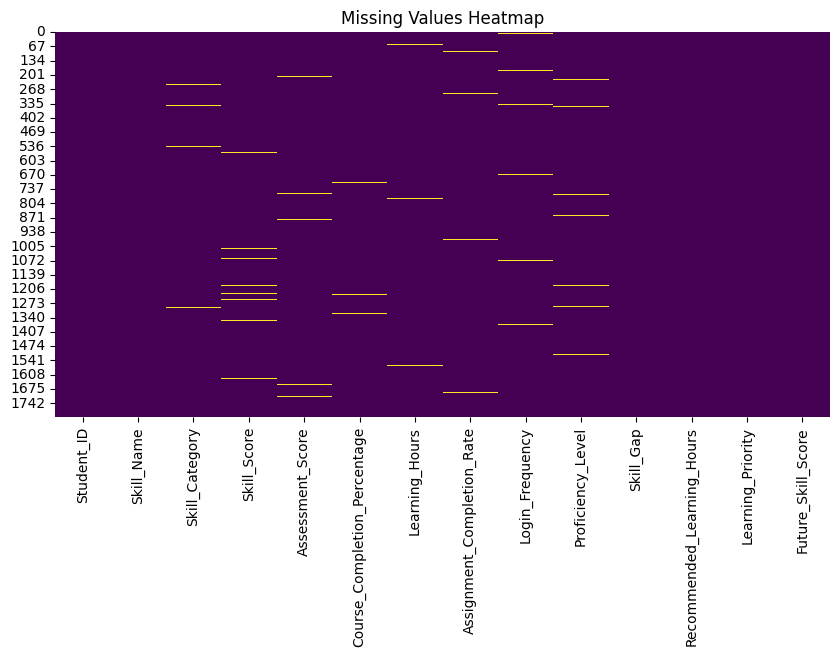

In [5]:
print("Missing Values Before Cleaning:\n")
print(df.isnull().sum())
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [6]:
# Numerical columns
num_cols = [
    'Skill_Score',
    'Assessment_Score',
    'Course_Completion_Percentage',
    'Learning_Hours',
    'Assignment_Completion_Rate',
    'Login_Frequency'
]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col].fillna(df[col].median(), inplace=True)
# Categorical columns
cat_cols = [
    'Skill_Category',
    'Proficiency_Level'
]
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing Values After Cleaning:\n")
print(df.isnull().sum())

Missing Values After Cleaning:

Student_ID                      0
Skill_Name                      0
Skill_Category                  0
Skill_Score                     0
Assessment_Score                0
Course_Completion_Percentage    0
Learning_Hours                  0
Assignment_Completion_Rate      0
Login_Frequency                 0
Proficiency_Level               0
Skill_Gap                       0
Recommended_Learning_Hours      0
Learning_Priority               0
Future_Skill_Score              0
dtype: int64


In [7]:
print("Rows Before:", len(df))
duplicates = df.duplicated().sum()
print("Duplicate Rows Found:", duplicates)
df = df.drop_duplicates()
print("Rows After:", len(df))

Rows Before: 1807
Duplicate Rows Found: 28
Rows After: 1779


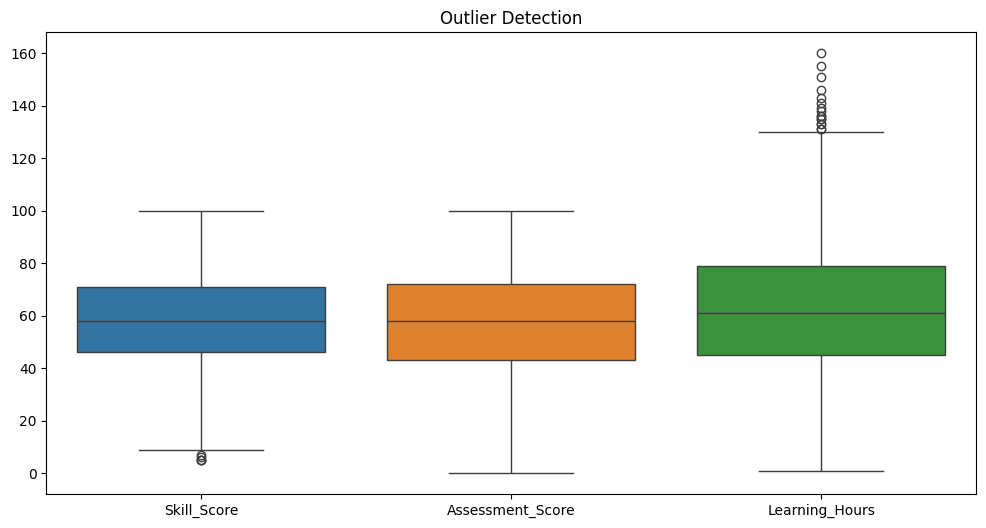

In [8]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df[
        [
            'Skill_Score',
            'Assessment_Score',
            'Learning_Hours'
        ]
    ]
)
plt.title("Outlier Detection")
plt.show()

In [9]:
from sklearn.preprocessing import LabelEncoder
le_skill = LabelEncoder()
le_category = LabelEncoder()
le_prof = LabelEncoder()
df['Skill_Name_Encoded'] = le_skill.fit_transform(df['Skill_Name'])
df['Skill_Category_Encoded'] = le_category.fit_transform(df['Skill_Category'])
df['Proficiency_Level_Encoded'] = le_prof.fit_transform(df['Proficiency_Level'])
df.head()

,Student_ID,Skill_Name,Skill_Category,Skill_Score,Assessment_Score,Course_Completion_Percentage,Learning_Hours,Assignment_Completion_Rate,Login_Frequency,Proficiency_Level,Skill_Gap,Recommended_Learning_Hours,Learning_Priority,Future_Skill_Score,Skill_Name_Encoded,Skill_Category_Encoded,Proficiency_Level_Encoded
0,S064,Node.js,Web Development,22.0,33.0,13.0,66.0,22.0,0.0,Beginner,63,57,High,32,19,10,1
1,S070,JavaScript,Web Development,64.0,53.0,36.0,49.0,35.0,7.0,Intermediate,21,23,Medium,42,16,10,2
2,S055,Git & GitHub,Tools,38.0,52.0,61.0,45.0,42.0,16.0,Beginner,47,44,High,41,13,9,1
3,S030,CSS,Web Development,52.0,36.0,62.0,33.0,41.0,13.0,Beginner,33,34,High,62,3,10,1
4,S065,Problem Solving,Soft Skills,46.0,63.0,66.0,107.0,60.0,4.0,Beginner,39,24,High,42,22,8,1


In [10]:
scaler = StandardScaler()
scale_cols = [
    'Skill_Score',
    'Assessment_Score',
    'Course_Completion_Percentage',
    'Learning_Hours',
    'Assignment_Completion_Rate',
    'Login_Frequency'
]
df[scale_cols] = scaler.fit_transform(df[scale_cols])
df.head()

,Student_ID,Skill_Name,Skill_Category,Skill_Score,Assessment_Score,Course_Completion_Percentage,Learning_Hours,Assignment_Completion_Rate,Login_Frequency,Proficiency_Level,Skill_Gap,Recommended_Learning_Hours,Learning_Priority,Future_Skill_Score,Skill_Name_Encoded,Skill_Category_Encoded,Proficiency_Level_Encoded
0,S064,Node.js,Web Development,-1.938896,-1.160487,-1.817542,0.125810,-1.480622,-1.737658,Beginner,63,57,High,32,19,10,1
1,S070,JavaScript,Web Development,0.332156,-0.217855,-0.833833,-0.543709,-0.916526,-0.486195,Intermediate,21,23,Medium,42,16,10,2
2,S055,Git & GitHub,Tools,-1.073733,-0.264986,0.235415,-0.701243,-0.612782,1.122830,Beginner,47,44,High,41,13,9,1
3,S030,CSS,Web Development,-0.316716,-1.019092,0.278185,-1.173845,-0.656174,0.586488,Beginner,33,34,High,62,3,10,1
4,S065,Problem Solving,Soft Skills,-0.641152,0.253462,0.449265,1.740533,0.168275,-1.022536,Beginner,39,24,High,42,22,8,1


In [11]:
df.to_csv("cleaned_skill_dataset.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


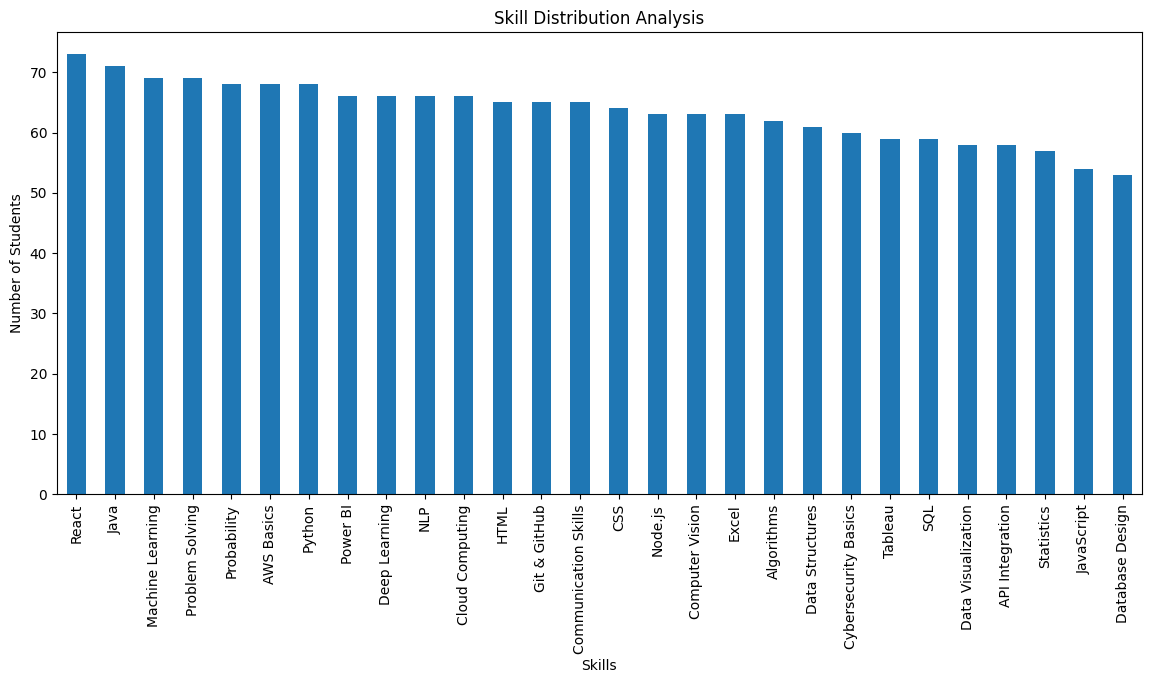

In [13]:
plt.figure(figsize=(14,6))
df['Skill_Name'].value_counts().plot(kind='bar')
plt.title("Skill Distribution Analysis")
plt.xlabel("Skills")
plt.ylabel("Number of Students")
plt.xticks(rotation=90)
plt.show()

In [14]:
top_skills = df.groupby('Skill_Name')['Skill_Score'].mean().sort_values(ascending=False)
print("Top 10 Highest Proficiency Skills\n")
print(top_skills.head(10))

Top 10 Highest Proficiency Skills

Skill_Name
Algorithms              0.523155
Git & GitHub            0.498534
Communication Skills    0.458603
Data Structures         0.400412
Power BI                0.319867
Database Design         0.316853
Java                    0.305501
Tableau                 0.303745
Python                  0.301939
Excel                   0.243752
Name: Skill_Score, dtype: float64


In [15]:
skill_gap = df.groupby('Skill_Name')['Skill_Gap'].mean().sort_values(ascending=False)

print(skill_gap.head(10))

Skill_Name
Machine Learning        38.913043
Deep Learning           38.515152
NLP                     35.924242
Cybersecurity Basics    35.250000
Statistics              34.824561
Probability             34.426471
AWS Basics              33.779412
Computer Vision         33.428571
API Integration         32.344828
Cloud Computing         31.454545
Name: Skill_Gap, dtype: float64


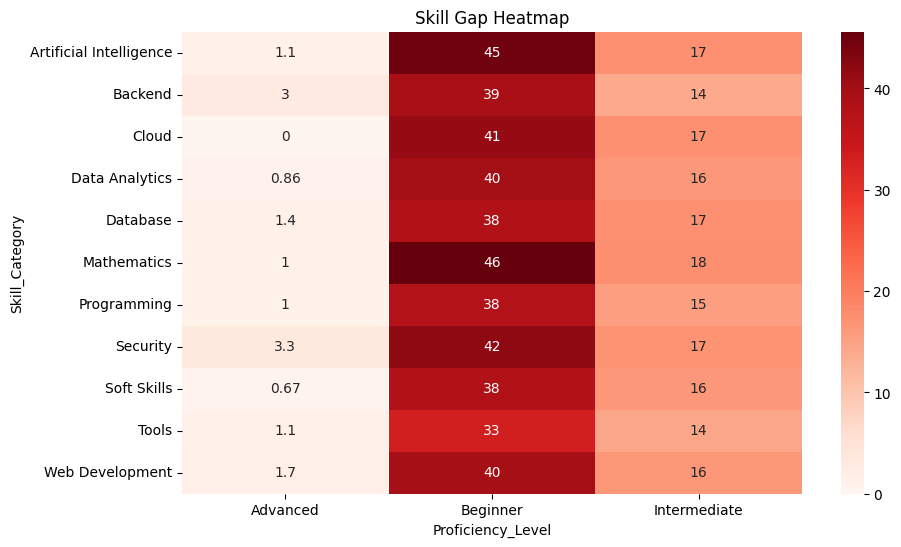

In [16]:
gap_data = df.pivot_table(
    values='Skill_Gap',
    index='Skill_Category',
    columns='Proficiency_Level',
    aggfunc='mean'
)
plt.figure(figsize=(10,6))
sns.heatmap(
    gap_data,
    annot=True,
    cmap='Reds'
)
plt.title("Skill Gap Heatmap")
plt.show()

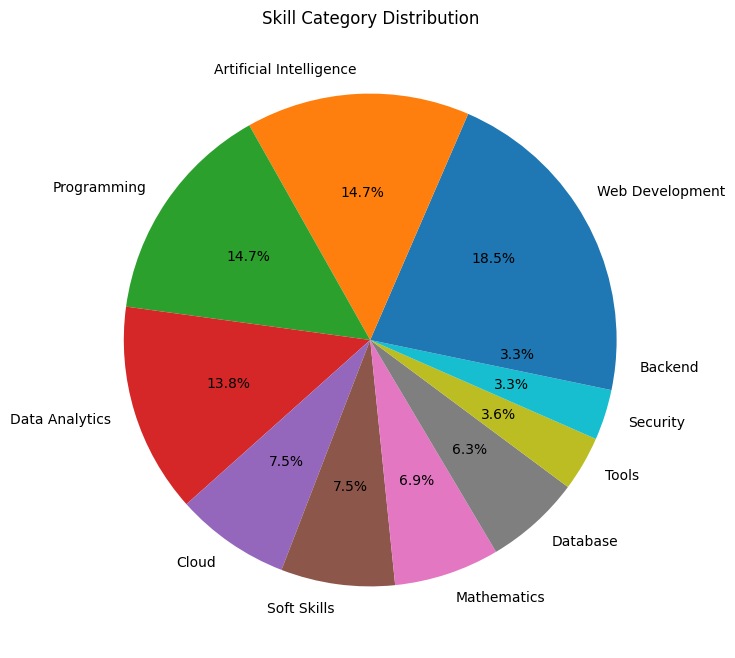

In [17]:
plt.figure(figsize=(8,8))
df['Skill_Category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.ylabel("")

plt.title("Skill Category Distribution")

plt.show()

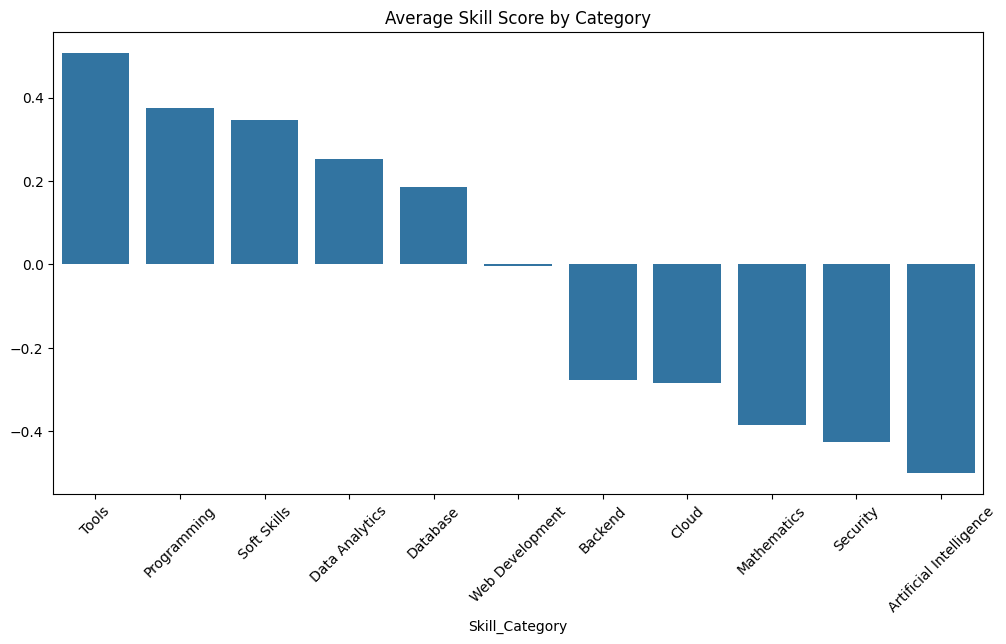

In [18]:
category_scores = df.groupby(
    'Skill_Category'
)['Skill_Score'].mean().sort_values(
    ascending=False
)
plt.figure(figsize=(12,6))
sns.barplot(
    x=category_scores.index,
    y=category_scores.values
)
plt.xticks(rotation=45)

plt.title("Average Skill Score by Category")

plt.show()

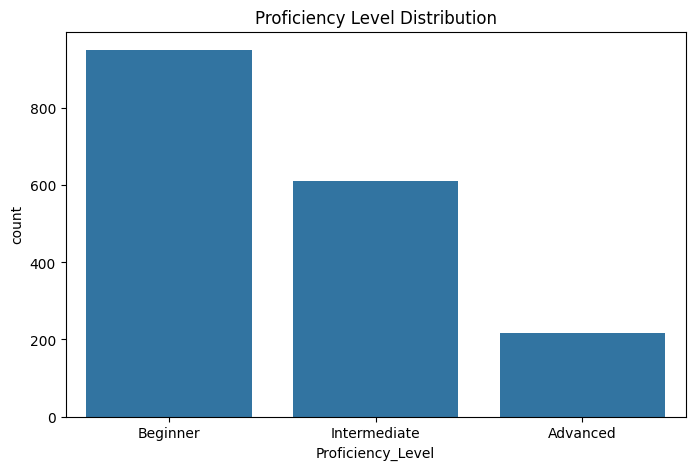

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Proficiency_Level',
    data=df
)

plt.title("Proficiency Level Distribution")

plt.show()

In [21]:
print("Highest Proficiency Skills")
print(top_skills.head(5))

print("\nLargest Skill Gaps")
print(skill_gap.head(5))

Highest Proficiency Skills
Skill_Name
Algorithms              0.523155
Git & GitHub            0.498534
Communication Skills    0.458603
Data Structures         0.400412
Power BI                0.319867
Name: Skill_Score, dtype: float64

Largest Skill Gaps
Skill_Name
Machine Learning        38.913043
Deep Learning           38.515152
NLP                     35.924242
Cybersecurity Basics    35.250000
Statistics              34.824561
Name: Skill_Gap, dtype: float64


In [22]:
student_df = df.groupby('Student_ID').agg({
    'Skill_Score':'mean',
    'Assessment_Score':'mean',
    'Course_Completion_Percentage':'mean',
    'Learning_Hours':'mean',
    'Assignment_Completion_Rate':'mean',
    'Login_Frequency':'mean'
}).reset_index()

student_df.head()

,Student_ID,Skill_Score,Assessment_Score,Course_Completion_Percentage,Learning_Hours,Assignment_Completion_Rate,Login_Frequency
0,S001,-0.772954,-0.594908,-0.609291,0.627950,-0.569389,-0.452673
1,S002,0.602520,0.373433,-0.168955,-0.386175,-0.123635,-0.014864
2,S003,1.062137,0.900212,0.634601,-0.836897,0.693801,0.477234
3,S004,-0.030131,-0.010475,-0.063975,-0.110491,0.012064,-0.003487
4,S005,-0.110256,0.034942,0.068223,0.175935,0.239280,0.375202


In [23]:

features = student_df.drop('Student_ID', axis=1)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

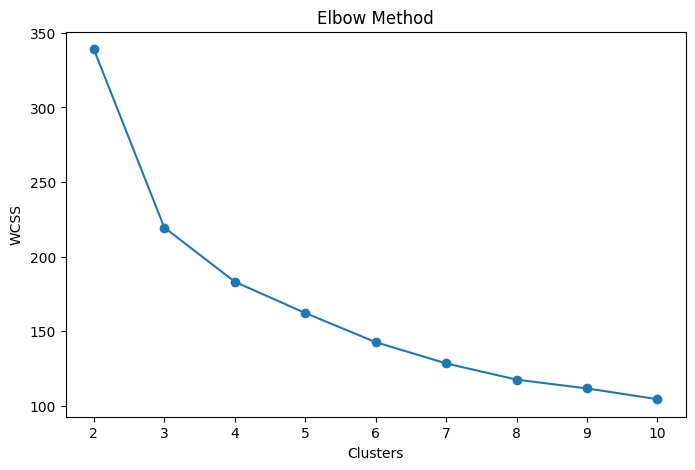

In [24]:
wcss = []

for i in range(2,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")

plt.show()

In [25]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

student_df['Cluster'] = kmeans.fit_predict(
    scaled_features
)

student_df.head()

,Student_ID,Skill_Score,Assessment_Score,Course_Completion_Percentage,Learning_Hours,Assignment_Completion_Rate,Login_Frequency,Cluster
0,S001,-0.772954,-0.594908,-0.609291,0.627950,-0.569389,-0.452673,1
1,S002,0.602520,0.373433,-0.168955,-0.386175,-0.123635,-0.014864,0
2,S003,1.062137,0.900212,0.634601,-0.836897,0.693801,0.477234,2
3,S004,-0.030131,-0.010475,-0.063975,-0.110491,0.012064,-0.003487,0
4,S005,-0.110256,0.034942,0.068223,0.175935,0.239280,0.375202,0


In [26]:
score = silhouette_score(
    scaled_features,
    student_df['Cluster']
)

print("Silhouette Score:", score)

Silhouette Score: 0.37623193671231


In [27]:
cluster_means = student_df.groupby(
    'Cluster'
)['Skill_Score'].mean()

print(cluster_means)

Cluster
0    0.010493
1   -0.695348
2    0.663052
Name: Skill_Score, dtype: float64


In [28]:
mapping = {
    0:'Beginner',
    1:'Intermediate',
    2:'Advanced'
}

student_df['Learner_Group'] = student_df[
    'Cluster'
].map(mapping)

student_df.head()

,Student_ID,Skill_Score,Assessment_Score,Course_Completion_Percentage,Learning_Hours,Assignment_Completion_Rate,Login_Frequency,Cluster,Learner_Group
0,S001,-0.772954,-0.594908,-0.609291,0.627950,-0.569389,-0.452673,1,Intermediate
1,S002,0.602520,0.373433,-0.168955,-0.386175,-0.123635,-0.014864,0,Beginner
2,S003,1.062137,0.900212,0.634601,-0.836897,0.693801,0.477234,2,Advanced
3,S004,-0.030131,-0.010475,-0.063975,-0.110491,0.012064,-0.003487,0,Beginner
4,S005,-0.110256,0.034942,0.068223,0.175935,0.239280,0.375202,0,Beginner


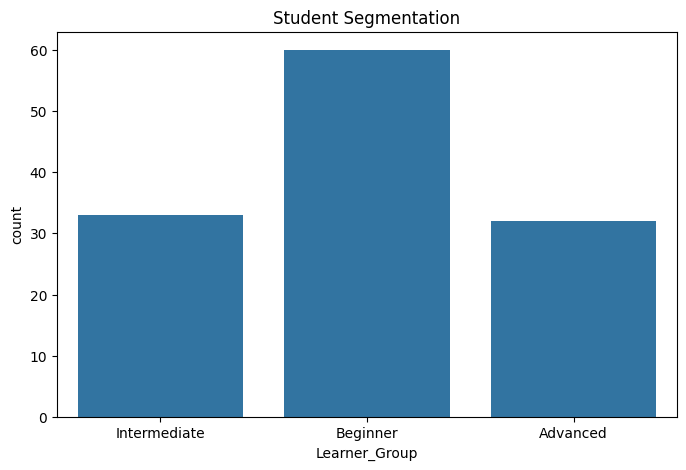

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Learner_Group',
    data=student_df
)

plt.title("Student Segmentation")

plt.show()

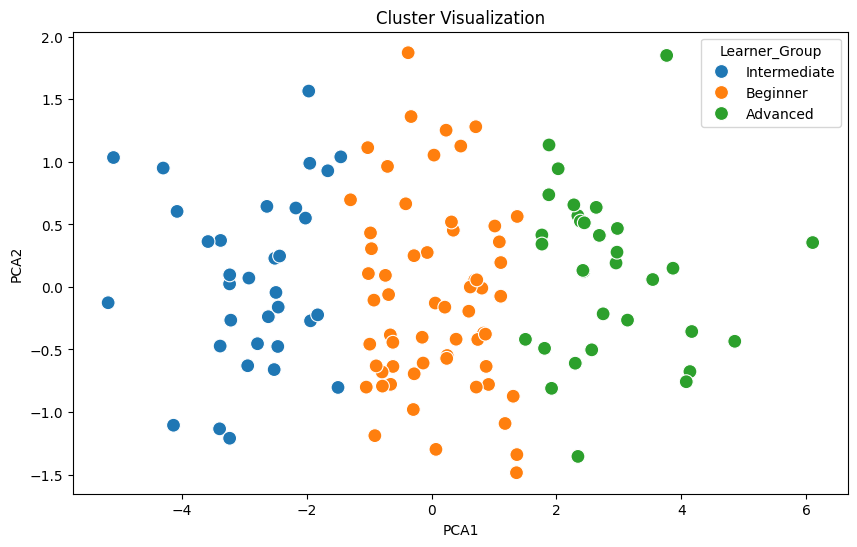

In [34]:
pca = PCA(n_components=2)
pca_features = pca.fit_transform(
    scaled_features
)
student_df['PCA1'] = pca_features[:,0]
student_df['PCA2'] = pca_features[:,1]
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Learner_Group',
    data=student_df,
    s=100
)

plt.title("Cluster Visualization")

plt.show()

In [35]:
student_df.groupby(
    'Learner_Group'
).mean(numeric_only=True)

,Skill_Score,Assessment_Score,Course_Completion_Percentage,Learning_Hours,Assignment_Completion_Rate,Login_Frequency,Cluster,PCA1,PCA2
Learner_Group,,,,,,,,,
Advanced,0.663052,0.565929,0.505024,-0.443076,0.537979,0.389275,2.0,2.833301,0.112667
Beginner,0.010493,0.030586,0.012050,-0.009621,0.011292,-0.039837,0.0,0.066636,-0.094565
Intermediate,-0.695348,-0.640348,-0.536124,0.442731,-0.580269,-0.345965,1.0,-2.868600,0.062683


In [36]:
basket = pd.crosstab(
    df['Student_ID'],
    df['Skill_Name']
)

basket.head()

Skill_Name,API Integration,AWS Basics,Algorithms,CSS,Cloud Computing,Communication Skills,Computer Vision,Cybersecurity Basics,Data Structures,Data Visualization,...,NLP,Node.js,Power BI,Probability,Problem Solving,Python,React,SQL,Statistics,Tableau
Student_ID,,,,,,,,,,,,,,,,,,,,,
S001,1,1,1,0,1,1,0,0,1,0,...,1,0,1,0,1,0,1,1,0,1
S002,0,0,1,0,0,0,0,1,1,0,...,1,1,0,1,0,0,0,0,0,0
S003,1,1,1,0,1,0,1,1,1,1,...,0,0,0,1,1,1,0,1,1,0
S004,0,1,1,0,1,0,0,0,0,0,...,0,0,1,1,1,1,1,0,0,0
S005,1,0,0,0,0,0,0,0,0,1,...,0,1,0,0,1,1,1,1,0,1


In [37]:
basket = basket.applymap(
    lambda x: 1 if x > 0 else 0
)

basket.head()

Skill_Name,API Integration,AWS Basics,Algorithms,CSS,Cloud Computing,Communication Skills,Computer Vision,Cybersecurity Basics,Data Structures,Data Visualization,...,NLP,Node.js,Power BI,Probability,Problem Solving,Python,React,SQL,Statistics,Tableau
Student_ID,,,,,,,,,,,,,,,,,,,,,
S001,1,1,1,0,1,1,0,0,1,0,...,1,0,1,0,1,0,1,1,0,1
S002,0,0,1,0,0,0,0,1,1,0,...,1,1,0,1,0,0,0,0,0,0
S003,1,1,1,0,1,0,1,1,1,1,...,0,0,0,1,1,1,0,1,1,0
S004,0,1,1,0,1,0,0,0,0,0,...,0,0,1,1,1,1,1,0,0,0
S005,1,0,0,0,0,0,0,0,0,1,...,0,1,0,0,1,1,1,1,0,1


In [38]:
frequent_itemsets = apriori(
    basket,
    min_support=0.10,
    use_colnames=True
)

frequent_itemsets.head()

,support,itemsets
0,0.464,(API Integration)
1,0.544,(AWS Basics)
2,0.496,(Algorithms)
3,0.512,(CSS)
4,0.528,(Cloud Computing)


In [39]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.50
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(API Integration),(AWS Basics),0.464,0.544,0.240,0.517241,0.950811,1.0,-0.012416,0.944571,-0.088022,0.312500,-0.058681,0.479209
1,(API Integration),(CSS),0.464,0.512,0.248,0.534483,1.043912,1.0,0.010432,1.048296,0.078479,0.340659,0.046071,0.509429
2,(API Integration),(Cloud Computing),0.464,0.528,0.248,0.534483,1.012278,1.0,0.003008,1.013926,0.022629,0.333333,0.013735,0.502090
3,(API Integration),(Communication Skills),0.464,0.520,0.240,0.517241,0.994695,1.0,-0.001280,0.994286,-0.009852,0.322581,-0.005747,0.489390
4,(API Integration),(Data Structures),0.464,0.488,0.248,0.534483,1.095252,1.0,0.021568,1.099852,0.162253,0.352273,0.090787,0.521340


In [40]:
rules = rules.sort_values(
    by='confidence',
    ascending=False
)
rules[
    [
        'antecedents',
        'consequents',
        'support',
        'confidence',
        'lift'
    ]
].head(15)

,antecedents,consequents,support,confidence,lift
14800,"(Probability, Machine Learning, Data Structure...",(Deep Learning),0.104,1.000000,1.893939
7363,"(SQL, AWS Basics, CSS)",(JavaScript),0.104,1.000000,2.314815
14787,"(Deep Learning, React, Git & GitHub, Data Stru...",(Communication Skills),0.112,1.000000,1.923077
14552,"(Algorithms, AWS Basics, HTML, Git & GitHub)",(Data Visualization),0.104,1.000000,2.155172
14669,"(Probability, AWS Basics, React, Statistics)",(Git & GitHub),0.104,1.000000,1.923077
14636,"(Statistics, AWS Basics, Computer Vision, Data...",(HTML),0.104,1.000000,1.923077
9499,"(Algorithms, Git & GitHub, Data Visualization)",(HTML),0.144,0.947368,1.821862
10759,"(Machine Learning, Cloud Computing, Deep Learn...",(Probability),0.136,0.944444,1.736111
12064,"(Computer Vision, Statistics, Data Visualization)",(HTML),0.136,0.944444,1.816239
2622,"(Database Design, JavaScript)",(CSS),0.128,0.941176,1.838235


In [41]:
top_rules = rules[
    [
        'antecedents',
        'consequents',
        'confidence',
        'lift'
    ]
].head(10)

print(top_rules)

                                             antecedents  \
14800  (Probability, Machine Learning, Data Structure...   
7363                              (SQL, AWS Basics, CSS)   
14787  (Deep Learning, React, Git & GitHub, Data Stru...   
14552       (Algorithms, AWS Basics, HTML, Git & GitHub)   
14669       (Probability, AWS Basics, React, Statistics)   
14636  (Statistics, AWS Basics, Computer Vision, Data...   
9499      (Algorithms, Git & GitHub, Data Visualization)   
10759  (Machine Learning, Cloud Computing, Deep Learn...   
12064  (Computer Vision, Statistics, Data Visualization)   
2622                       (Database Design, JavaScript)   

                  consequents  confidence      lift  
14800         (Deep Learning)    1.000000  1.893939  
7363             (JavaScript)    1.000000  2.314815  
14787  (Communication Skills)    1.000000  1.923077  
14552    (Data Visualization)    1.000000  2.155172  
14669          (Git & GitHub)    1.000000  1.923077  
14636          

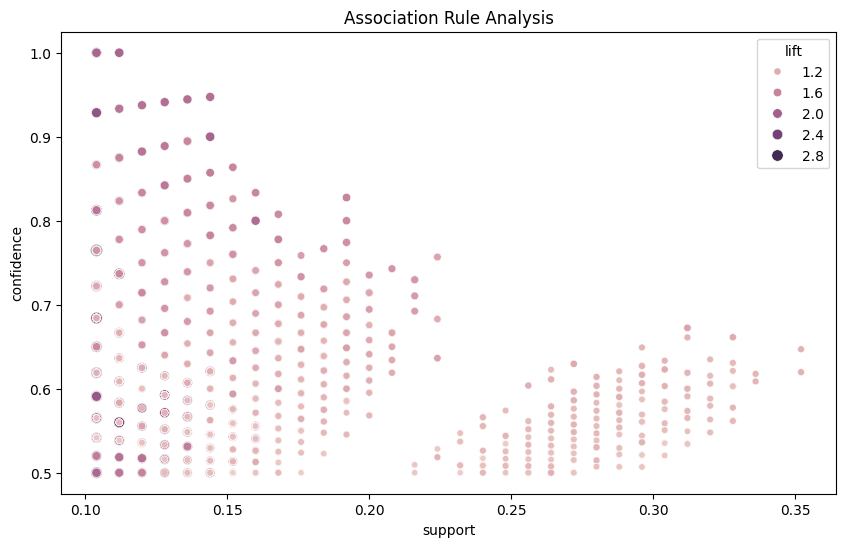

In [42]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rules,
    x='support',
    y='confidence',
    size='lift',
    hue='lift'
)

plt.title(
    "Association Rule Analysis"
)

plt.show()

In [43]:
print("Top Skill Combinations Learned Together\n")

for index,row in rules.head(10).iterrows():

    print(
        f"{set(row['antecedents'])} -> {set(row['consequents'])}"
    )

    print(
        f"Confidence: {row['confidence']:.2f}"
    )

    print(
        f"Lift: {row['lift']:.2f}"
    )

    print("-"*50)

Top Skill Combinations Learned Together

{'Probability', 'Machine Learning', 'Data Structures', 'Communication Skills'} -> {'Deep Learning'}
Confidence: 1.00
Lift: 1.89
--------------------------------------------------
{'SQL', 'AWS Basics', 'CSS'} -> {'JavaScript'}
Confidence: 1.00
Lift: 2.31
--------------------------------------------------
{'Deep Learning', 'React', 'Git & GitHub', 'Data Structures'} -> {'Communication Skills'}
Confidence: 1.00
Lift: 1.92
--------------------------------------------------
{'Algorithms', 'AWS Basics', 'HTML', 'Git & GitHub'} -> {'Data Visualization'}
Confidence: 1.00
Lift: 2.16
--------------------------------------------------
{'Probability', 'AWS Basics', 'React', 'Statistics'} -> {'Git & GitHub'}
Confidence: 1.00
Lift: 1.92
--------------------------------------------------
{'Statistics', 'AWS Basics', 'Computer Vision', 'Data Visualization'} -> {'HTML'}
Confidence: 1.00
Lift: 1.92
--------------------------------------------------
{'Algorithms',

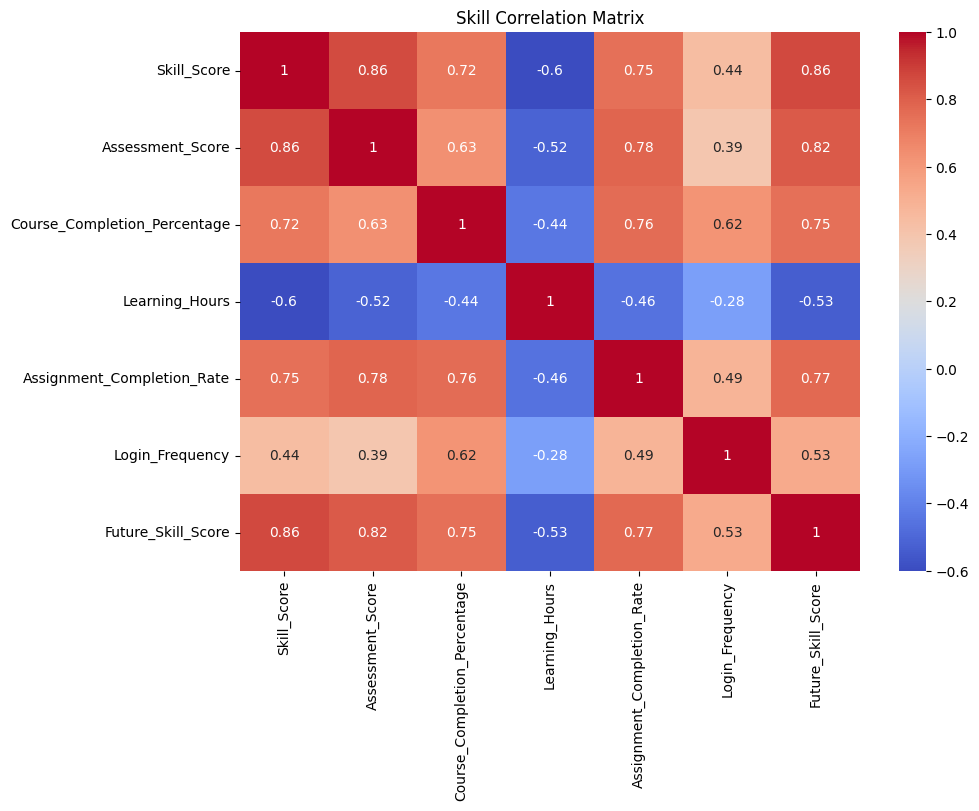

In [44]:
corr_cols = [
    'Skill_Score',
    'Assessment_Score',
    'Course_Completion_Percentage',
    'Learning_Hours',
    'Assignment_Completion_Rate',
    'Login_Frequency',
    'Future_Skill_Score'
]

corr_matrix = df[
    corr_cols
].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title(
    "Skill Correlation Matrix"
)

plt.show()

In [45]:
corr_matrix

,Skill_Score,Assessment_Score,Course_Completion_Percentage,Learning_Hours,Assignment_Completion_Rate,Login_Frequency,Future_Skill_Score
Skill_Score,1.000000,0.857957,0.721613,-0.600640,0.745421,0.440171,0.864517
Assessment_Score,0.857957,1.000000,0.632135,-0.517648,0.781262,0.392624,0.818114
Course_Completion_Percentage,0.721613,0.632135,1.000000,-0.443836,0.757683,0.623510,0.747676
Learning_Hours,-0.600640,-0.517648,-0.443836,1.000000,-0.458690,-0.279408,-0.534114
Assignment_Completion_Rate,0.745421,0.781262,0.757683,-0.458690,1.000000,0.486516,0.774208
Login_Frequency,0.440171,0.392624,0.623510,-0.279408,0.486516,1.000000,0.527321
Future_Skill_Score,0.864517,0.818114,0.747676,-0.534114,0.774208,0.527321,1.000000


In [46]:
features = [
    'Skill_Score',
    'Assessment_Score',
    'Course_Completion_Percentage',
    'Learning_Hours',
    'Assignment_Completion_Rate',
    'Login_Frequency',
    'Skill_Category_Encoded',
    'Proficiency_Level_Encoded'
]

X = df[features]

y = df['Future_Skill_Score']

In [47]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:",X_train.shape)
print("Testing Shape:",X_test.shape)

Training Shape: (1423, 8)
Testing Shape: (356, 8)


In [48]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [49]:
y_pred = rf.predict(X_test)

y_pred[:10]

array([85.87 , 34.12 , 58.155, 36.075, 56.62 , 66.165, 53.665, 64.675,
       72.045, 41.63 ])

In [50]:


mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE :",mae)
print("MSE :",mse)
print("R² Score :",r2)

MAE : 7.868497191011237
MSE : 86.69468110955056
R² Score : 0.7941174698324921


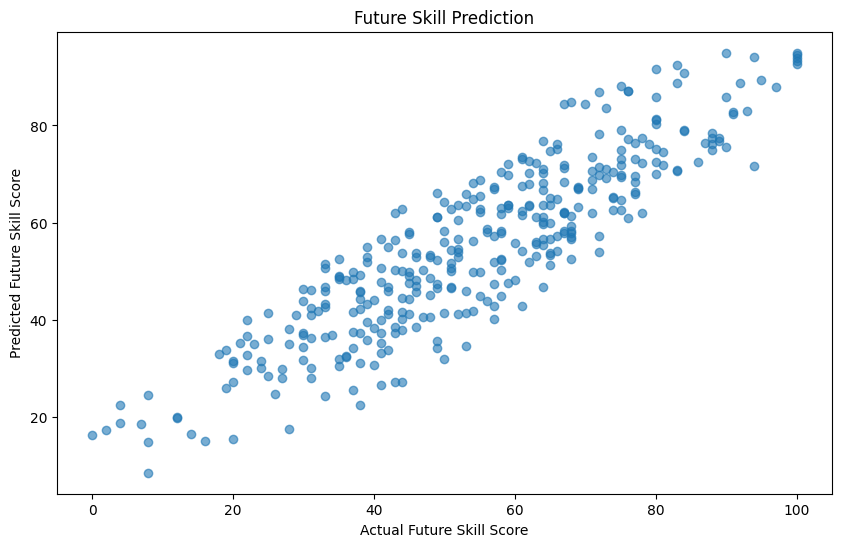

In [51]:
plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual Future Skill Score")
plt.ylabel("Predicted Future Skill Score")

plt.title(
    "Future Skill Prediction"
)

plt.show()

In [52]:
comparison = pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
})

comparison.head(20)

,Actual,Predicted
1206,90,85.870
429,49,34.120
1495,56,58.155
772,25,36.075
489,52,56.620
483,49,66.165
109,65,53.665
782,75,64.675
1452,59,72.045
1202,37,41.630


In [53]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
0,Skill_Score,0.753860
2,Course_Completion_Percentage,0.054979
4,Assignment_Completion_Rate,0.052205
1,Assessment_Score,0.049841
5,Login_Frequency,0.033410
3,Learning_Hours,0.031052
6,Skill_Category_Encoded,0.016647
7,Proficiency_Level_Encoded,0.008006


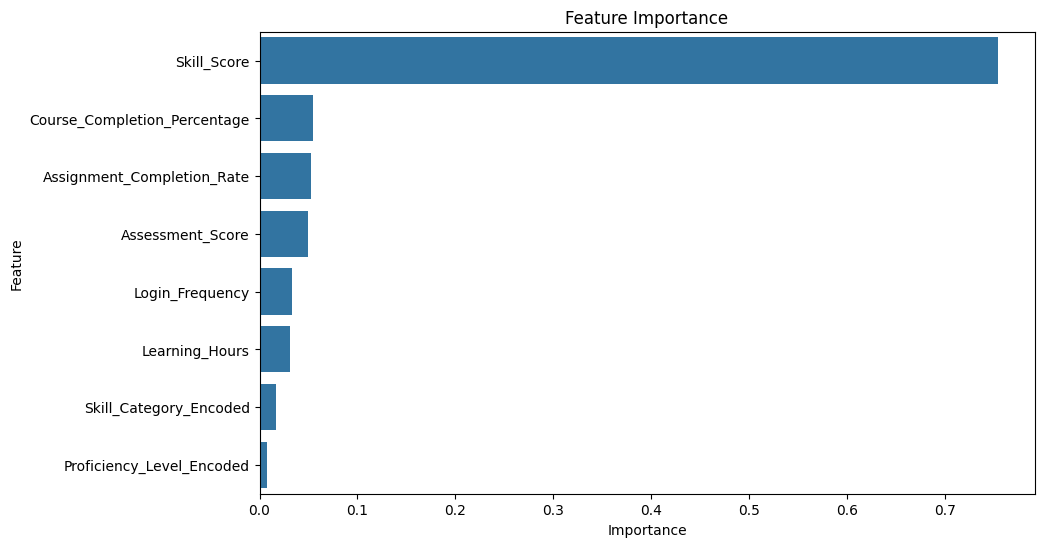

In [54]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title(
    "Feature Importance"
)

plt.show()

In [55]:
recommendations = df[
    [
        'Student_ID',
        'Skill_Name',
        'Skill_Score',
        'Recommended_Learning_Hours',
        'Learning_Priority'
    ]
]

recommendations = recommendations[
    recommendations['Skill_Score'] < 60
]

recommendations = recommendations.sort_values(
    by='Skill_Score'
)

recommendations.head(20)

,Student_ID,Skill_Name,Skill_Score,Recommended_Learning_Hours,Learning_Priority
1057,S080,Machine Learning,-2.858131,80,High
1559,S080,Deep Learning,-2.858131,64,High
155,S064,Computer Vision,-2.858131,76,High
1769,S040,Node.js,-2.804058,57,High
435,S053,Deep Learning,-2.749986,74,High
718,S106,Probability,-2.641840,50,High
1103,S082,Excel,-2.641840,39,High
1036,S066,Excel,-2.587768,61,High
1437,S085,Probability,-2.587768,45,High
1805,S035,Deep Learning,-2.587768,48,High


In [56]:
high_priority = recommendations[
    recommendations['Learning_Priority'] == 'High'
]

high_priority.head(15)

,Student_ID,Skill_Name,Skill_Score,Recommended_Learning_Hours,Learning_Priority
1057,S080,Machine Learning,-2.858131,80,High
1559,S080,Deep Learning,-2.858131,64,High
155,S064,Computer Vision,-2.858131,76,High
1769,S040,Node.js,-2.804058,57,High
435,S053,Deep Learning,-2.749986,74,High
718,S106,Probability,-2.641840,50,High
1103,S082,Excel,-2.641840,39,High
1036,S066,Excel,-2.587768,61,High
1437,S085,Probability,-2.587768,45,High
1805,S035,Deep Learning,-2.587768,48,High


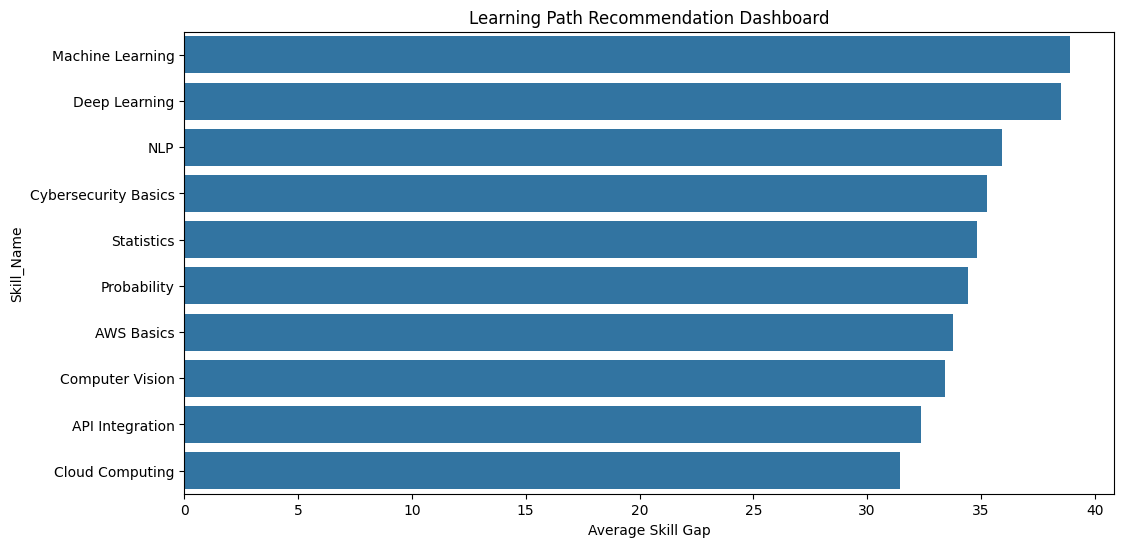

In [58]:
plt.figure(figsize=(12,6))

top_gap_skills = df.groupby(
    'Skill_Name'
)['Skill_Gap'].mean().sort_values(
    ascending=False
).head(10)

sns.barplot(
    x=top_gap_skills.values,
    y=top_gap_skills.index
)

plt.title(
    "Learning Path Recommendation Dashboard"
)

plt.xlabel("Average Skill Gap")

plt.show()

In [59]:
recommended_skills = df.groupby(
    'Skill_Name'
)['Skill_Gap'].mean().sort_values(
    ascending=False
)

recommended_skills.head(10)

,Skill_Gap
Skill_Name,
Machine Learning,38.913043
Deep Learning,38.515152
NLP,35.924242
Cybersecurity Basics,35.250000
Statistics,34.824561
Probability,34.426471
AWS Basics,33.779412
Computer Vision,33.428571
API Integration,32.344828


In [61]:
summary = pd.DataFrame({
    "Metric":[
        "Silhouette Score",
        "MAE",
        "MSE",
        "R2 Score"
    ],
    "Value":[
        score,
        mae,
        mse,
        r2
    ]
})

summary

,Metric,Value
0,Silhouette Score,0.376232
1,MAE,7.868497
2,MSE,86.694681
3,R2 Score,0.794117
